# Run the might and other models on the cancer data

In [2]:
# import libraries
import tarfile
import os
import numpy as np
from scipy.stats import multivariate_normal
from scipy.stats import entropy
from sklearn import metrics
from sklearn.metrics import roc_auc_score

# import matplotlib.pyplot as plt
# import seaborn as sns
import pandas as pd
import warnings
import string
warnings.filterwarnings("ignore")

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

from sktree.stats import build_oob_forest
from sktree.ensemble import HonestForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [3]:
# load the .tar.gz file
# tarfile.open("./ManuscriptFeatureMatrices.tar.gz", "r:gz").extractall()

# load the data
# filelist = os.listdir("./ManuscriptFeatureMatrices")
# filelist = [f for f in filelist if f.endswith(".csv")]
# n_files = len(filelist)
# import the filelist.txt as a list
with open("./filelist.txt") as f:
    filelist = f.readlines()
filelist = [x.strip() for x in filelist]
print(filelist)

# get the sample list
sample_list_file = "./ManuscriptFeatureMatrices/AllSamples.MIGHT.Passed.samples.txt"
sample_list = pd.read_csv(sample_list_file, sep=" ", header=None)
sample_list.columns = ["library", "sample_id", "cohort"]
sample_list.head()
# get the sample_ids where cohort is Cohort1
cohort1 = sample_list[sample_list["cohort"] == "Cohort1"]["sample_id"]
cohort2 = sample_list[sample_list["cohort"] == "Cohort2"]["sample_id"]
# print(cohort1)

['LociFraction.AluFraction.csv', 'LociFraction.cCREFraction.csv', 'LociFraction.LINEsFraction.csv', 'MotifAnalysis.CongruentDimer.csv', 'MotifAnalysis.CongruentHexamer.csv', 'MotifAnalysis.CongruentTetramer.csv', 'MotifAnalysis.DegenerateHexamer.csv', 'MotifAnalysis.DegenerateTetramer.csv', 'MotifAnalysis.InsideDimer.csv', 'MotifAnalysis.InsideHexamer.csv', 'MotifAnalysis.InsideMonomer.csv', 'MotifAnalysis.InsidePentamer.csv', 'MotifAnalysis.InsideTetramer.csv', 'MotifAnalysis.InsideTrimer.csv', 'MotifAnalysis.InsideTrimer0.01.csv', 'MotifAnalysis.InsideTrimer0.05.csv', 'MotifAnalysis.OutsideDimer.csv', 'MotifAnalysis.OutsideHexamer.csv', 'MotifAnalysis.OutsideMonomer.csv', 'MotifAnalysis.OutsidePentamer.csv', 'MotifAnalysis.OutsideTetramer.csv', 'MotifAnalysis.OutsideTrimer.csv', 'WiseCondorX.Wise-1.csv', 'WiseCondorX.Wise-5.csv', 'WiseCondorX.Wise-10.csv', 'Delfi.LengthRatio.csv', 'DyadAccessibility.AluJ.csv', 'DyadAccessibility.AluS.csv', 'DyadAccessibility.AluY.csv', 'DyadAccessibi

In [4]:
# define a function to get X and y given a file

def get_X_y(f, root="./ManuscriptFeatureMatrices/", cohort=cohort1, verbose=False):
    df = pd.read_csv(root + f)
    non_features = ['Run', 'Sample', 'Library', 'Cancer Status', 'Tumor type', 'Stage', 'Library volume (uL)', 'Library Volume', 'UIDs Used', 'Experiment', 'P7', 'P7 Primer', 'MAF']
    sample_ids = df["Sample"]
    # if sample is contains "Run" column, remove it
    for i, sample_id in enumerate(sample_ids):
        if "." in sample_id:
            sample_ids[i] = sample_id.split(".")[1]
    target = 'Cancer Status'
    y = df[target]
    # convert the labels to 0 and 1
    y = y.replace("Healthy", 0)
    y = y.replace("Cancer", 1)
    # remove the non-feature columns if they exist
    for col in non_features:
        if col in df.columns:
            df = df.drop(col, axis=1)
    nan_cols = df.isnull().all(axis=0).to_numpy()
    # drop the columns with all nan values
    df = df.loc[:, ~nan_cols]
    # if cohort is not None, filter the samples
    if cohort is not None:
        # filter the rows with cohort1 samples
        X = df[sample_ids.isin(cohort)]
        y = y[sample_ids.isin(cohort)]
    else:
        X = df
    if "Wise" in f:
        # replace nans with zero
        X = X.fillna(0)
    # impute the nan values with the mean of the column
    X = X.fillna(X.mean(axis=0))
    # check if there are nan values
    # nan_rows = X.isnull().any(axis=1)
    nan_cols = X.isnull().all(axis=0)
    # remove the columns with all nan values
    X = X.loc[:, ~nan_cols]
    if verbose:
        if nan_cols.sum() > 0:
            print(f)
            print(f"nan_cols: {nan_cols.sum()}")
            print(f"X shape: {X.shape}, y shape: {y.shape}")
        else:
            print(f)
            print(f"X shape: {X.shape}, y shape: {y.shape}")
    # X = X.dropna()
    # y = y.drop(nan_rows.index)
        
    return X, y


In [5]:
for i in range(len(filelist[:])):
    X, y = get_X_y(filelist[i], cohort=cohort2, verbose=False)
    print(filelist[i], X.shape)
    # calculate the y distribution
    # y_dist = y.value_counts(normalize=False)
    # print(y_dist)


LociFraction.AluFraction.csv (1447, 3)
LociFraction.cCREFraction.csv (1447, 5)
LociFraction.LINEsFraction.csv (1447, 3)
MotifAnalysis.CongruentDimer.csv (1447, 17)
MotifAnalysis.CongruentHexamer.csv (1447, 4097)
MotifAnalysis.CongruentTetramer.csv (1447, 257)
MotifAnalysis.DegenerateHexamer.csv (1447, 15361)
MotifAnalysis.DegenerateTetramer.csv (1447, 513)
MotifAnalysis.InsideDimer.csv (1447, 17)
MotifAnalysis.InsideHexamer.csv (1447, 4097)
MotifAnalysis.InsideMonomer.csv (1447, 5)
MotifAnalysis.InsidePentamer.csv (1447, 1025)
MotifAnalysis.InsideTetramer.csv (1447, 257)
MotifAnalysis.InsideTrimer.csv (1447, 65)
MotifAnalysis.InsideTrimer0.01.csv (1447, 3841)
MotifAnalysis.InsideTrimer0.05.csv (1447, 3585)
MotifAnalysis.OutsideDimer.csv (1447, 17)
MotifAnalysis.OutsideHexamer.csv (1447, 4097)
MotifAnalysis.OutsideMonomer.csv (1447, 5)
MotifAnalysis.OutsidePentamer.csv (1447, 1025)
MotifAnalysis.OutsideTetramer.csv (1447, 257)
MotifAnalysis.OutsideTrimer.csv (1447, 65)
WiseCondorX.Wise-

In [6]:
# N_ITR = 5
FIG_DIR = "./results/figures/"
clf_name = [
    "MIGHT",
    "Random Forest",
    "SVM",
    "Naive Bayes",
    "Logistic Regression",
]
n_clf = len(clf_name)
base_fpr = np.linspace(0, 1, 1001)
max_fpr = 0.02
# create a dataframe to store the results
results = pd.DataFrame()
results_per_run = pd.DataFrame()
for i in range(len(filelist)):
    FEATURENAME = filelist[i].split(".csv")[0]
    print(i, FEATURENAME)
    for j in range(n_clf):
        tpr_ = []
        sa98_ = []
        for k in range(N_ITR):
            tpr = np.interp(base_fpr, fprs[i+n_files*k][j], tprs[i+n_files*k][j])
            # print(tpr)
            tpr_i = np.mean(tpr, axis=0)
            tpr_.append(tpr_i)
            # tpr_std = np.std(tpr, axis=0)
            sa98_i = max([tpr for (base_fpr, tpr) in zip(base_fpr, tpr) if base_fpr <= max_fpr])
            sa98_.append(sa98_i)
            row = {
            "Feature": FEATURENAME,
            "Classifier": clf_name[j],
            "sa98": sa98_i,
            "tpr": tpr_i,
            }
            results_per_run = results_per_run._append(row, ignore_index=True)
        tpr_mean = np.mean(tpr_)
        sa98 = np.mean(sa98_)
        # print( " "*5, j+1, clf_name[j])
        # print(" "*10, "sa98:", sa98)
        # print(" "*10, "tpr:", tpr_mean)
        # add the results to the dataframe
        row = {
            "Feature": FEATURENAME,
            "Classifier": clf_name[j],
            "sa98": sa98,
            "tpr": tpr_mean,
        }
        results = results._append(row, ignore_index=True)
        
# display(results)
# sort the results s.t. the Classifier is in the order of ["MIGHT", "Random Forest", "SVM", "Naive Bayes", "Logistic Regression"]
df = results.set_index("Classifier").loc[["MIGHT", "Random Forest", "SVM", "Naive Bayes", "Logistic Regression"]].sort_values("Feature").reset_index()
display(df)
top5_features = df[df["Classifier"] == "MIGHT"].sort_values("sa98", ascending=False)[:5]["Feature"]
display(top5_features)

0 LociFraction.AluFraction


NameError: name 'N_ITR' is not defined

In [7]:
def run_models(filename, seed=123, n_jobs=-5, root="./ManuscriptFeatureMatrices/", cohort=cohort1, verbose=False):
    # get the data
    X, y = get_X_y(filename, root=root, cohort=cohort, verbose=verbose)

    lr = LogisticRegression(
        penalty="l2", solver="liblinear", n_jobs=n_jobs, random_state=seed
    )
    gnb = GaussianNB()
    #     svc = NaivelyCalibratedLinearSVC(C=1.0)
    svc = SVC(probability=True, kernel="rbf", random_state=seed)
    rfc = RandomForestClassifier(
        n_estimators=1200, max_features=0.3, n_jobs=n_jobs, random_state=seed
    )
    might = HonestForestClassifier(
        n_estimators=6000,
        max_samples=1.6,
        max_features=0.3,
        bootstrap=True,
        stratify=True,
        random_state=seed,
        n_jobs=n_jobs,
        honest_prior="ignore"
    )

    clf_list = [
        (might, "MIGHT"),
        (rfc, "Random Forest"),
        (svc, "SVM"),
        (gnb, "Naive Bayes"),
        (lr, "Logistic Regression"),
    ]

    fpr_s = []
    tpr_s = []
    for i, (clf, name) in enumerate(clf_list):
        # create a dictionary to hold the results
        fpr_i = {}
        tpr_i = {}
        if name == "MIGHT":
            _, observe_proba = build_oob_forest(clf, X, y)
            observe_proba = np.nanmean(observe_proba, axis=0)
            fpr, tpr, thresholds = roc_curve(
                y, observe_proba[:, 1], pos_label=1, drop_intermediate=False
            )
        else:
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, shuffle=True, stratify=y, test_size=0.2
            )

            X_fit, X_cal, y_fit, y_cal = train_test_split(
                X_train, y_train, test_size=0.5, stratify=y_train
            )
            clf.fit(X_fit, y_fit)

            if X_cal.shape[0] <= 1024:
                calibrated_model = CalibratedClassifierCV(
                    clf, cv="prefit", method="sigmoid"
                )
            else:
                calibrated_model = CalibratedClassifierCV(
                    clf, cv="prefit", method="isotonic"
                )
            calibrated_model.fit(X_cal, y_cal)
            posterior = calibrated_model.predict_proba(X_test)

            fpr, tpr, thresholds = roc_curve(
                y_test,
                posterior[:, 1],
                pos_label=1,
                drop_intermediate=False,
            )
        fpr_s.append(fpr)
        tpr_s.append(tpr)

    return clf_list, fpr_s, tpr_s

In [7]:
# import pickle

# # clfs = []
# # fprs = []
# # tprs = []

# N_ITR = 5
# N_JOBS = -3
# DIRECTORY = "./results/"
# VERSION = 2
# # create files to store the results if they don't exist
# save_files = [DIRECTORY + f + f"_{N_ITR}_{VERSION}.pkl" for f in ["fprs", "tprs", "clfs"]]
# for f in save_files:
#     if not os.path.exists(f):
#         with open(f, "wb") as f:
#             pickle.dump([], f)

# start = 0
# end = len(filelist)

# for i in range(N_ITR):
#     print(i)
#     # open the files to append the results
#     with open(DIRECTORY + f"fprs_{N_ITR}_{VERSION}.pkl", "rb") as f:
#         fprs = pickle.load(f)
#     with open(DIRECTORY + f"tprs_{N_ITR}_{VERSION}.pkl", "rb") as f:
#         tprs = pickle.load(f)
#     with open(DIRECTORY + f"clfs_{N_ITR}_{VERSION}.pkl", "rb") as f:
#         clfs = pickle.load(f)
#     for file in filelist[start:end]:
#         print(file)
#         try:
#             clf_list, fpr_s, tpr_s = run_models(file, seed=i)
#             clfs.append(clf_list)
#             fprs.append(fpr_s)
#             tprs.append(tpr_s)

#             # save the results
#             with open(DIRECTORY + f"fprs_{N_ITR}_{VERSION}.pkl", "wb") as f:
#                 pickle.dump(fprs, f)

#             with open(DIRECTORY + f"tprs_{N_ITR}_{VERSION}.pkl", "wb") as f:
#                 pickle.dump(tprs, f)

#             with open(DIRECTORY + f"clfs_{N_ITR}_{VERSION}.pkl", "wb") as f:
#                 pickle.dump(clfs, f)
#         except Exception as e:
#             print(file, e)
#             continue


In [8]:
DIRECTORY = "./results/"
N_ITR = 50
VERSION = 1

# with open(DIRECTORY + "clfs.pkl", "rb") as f:
#     clfs = pickle.load(f)
with open(DIRECTORY + f"fprs_{N_ITR}_{VERSION}.pkl", "rb") as f:
    fprs = pickle.load(f)
with open(DIRECTORY + f"tprs_{N_ITR}_{VERSION}.pkl", "rb") as f:
    tprs = pickle.load(f)

print(len(fprs))
print(len(tprs))
n_iter = int(len(fprs)/len(filelist))
print(n_iter)
# crop them to the last 440 items
# fprs = fprs[:44*n_iter]
# tprs = tprs[:44*n_iter]


# # save the results to a file
# with open(DIRECTORY + f"fprs_{N_ITR}_{VERSION}.pkl", "wb") as f:
#     pickle.dump(fprs, f)
# with open(DIRECTORY + f"tprs_{N_ITR}_{VERSION}.pkl", "wb") as f:
#     pickle.dump(tprs, f)


2200
2200
50


In [9]:
# print out the pallet "Set1" in hex format
colors = sns.color_palette("Set1", n_colors=10,as_cmap=False)
# swap second and fourth colors
colors[1], colors[3] = colors[3], colors[1]
colors

[(0.8941176470588236, 0.10196078431372549, 0.10980392156862745),
 (0.596078431372549, 0.3058823529411765, 0.6392156862745098),
 (0.30196078431372547, 0.6862745098039216, 0.2901960784313726),
 (0.21568627450980393, 0.49411764705882355, 0.7215686274509804),
 (1.0, 0.4980392156862745, 0.0),
 (1.0, 1.0, 0.2),
 (0.6509803921568628, 0.33725490196078434, 0.1568627450980392),
 (0.9686274509803922, 0.5058823529411764, 0.7490196078431373),
 (0.6, 0.6, 0.6),
 (0.8941176470588236, 0.10196078431372549, 0.10980392156862745)]

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
# set the style to Set1
# sns.set_palette("Set1")
# colors = sns.color_palette("Set1", n_colors=10,as_cmap=False)

FIG_DIR = "./results/figures/"
clf_names = [
    "MIGHT",
    "Random Forest",
    "SVM",
    "Naive Bayes",
    "Logistic Regression",
]
n_clf = len(clf_names)
# plot the ROC curve
base_fpr = np.linspace(0, 1, 1001)
N_ITR = int(len(fprs)/len(filelist))
fpr_ls = np.zeros((N_ITR, n_clf, 1001))
tpr_ls = np.zeros((N_ITR, n_clf, 1001))
feature_mean_s = []
n_files = len(filelist)
for i, filename in enumerate(filelist):
    FEATURENAME = filename.split(".csv")[0]
    if FEATURENAME in list(top5_features):
        print(FEATURENAME)
        # initialize a figure
        fig, ax = plt.subplots(figsize=(10, 10))
        for j, clf_name_ in enumerate(clf_names):
            tpr_s = []
            for k in range(N_ITR):
                tpr_interpolated = np.interp(base_fpr, fprs[n_files*k+i][j], tprs[n_files*k+i][j])
                tpr_s.append(tpr_interpolated)
        # print(tpr.shape)
            tpr_s = np.array(tpr_s)
            # print(tpr_s.shape)
            # print(np.mean(tpr_s, axis=0).shape)
            # plot the tpr_s with confidence intervals
            ax.plot(base_fpr, np.mean(tpr_s, axis=0), label=clf_names[j], color=colors[j])
            # ax.plot(base_fpr, np.max(tpr_s, axis=0), label=clf_names[j]+"(max)", color=colors[j])
            # ax.plot(base_fpr, np.min(tpr_s, axis=0), label=clf_names[j]+"(min)", color=colors[j])
            # plot the confidence intervals
            # ax.fill_between(
            #     base_fpr,
            #     np.max(tpr_s, axis=0),
            #     np.min(tpr_s, axis=0),
            #     color=colors[j],
            #     alpha=0.3,
            # )
        plt.legend(fontsize=10)
        ax.plot([0,1], [0,1], "--", color="gray")
        ax.set_xlabel("False Positive Rate", fontsize=15)
        ax.set_ylabel("True Positive Rate", fontsize=15)
        ax.tick_params(axis="both", labelsize=15)
        plt.title(f"{FEATURENAME}", fontsize=15)
        # plt.savefig(FIG_DIR + "roc_" + str(FEATURENAME) + ".png", dpi=120)
    

NameError: name 'top5_features' is not defined

WiseCondorX.Wise-1
MotifAnalysis.OutsideMonomer
WiseCondorX.Wise-10
MotifAnalysis.InsideHexamer
MotifAnalysis.DegenerateHexamer


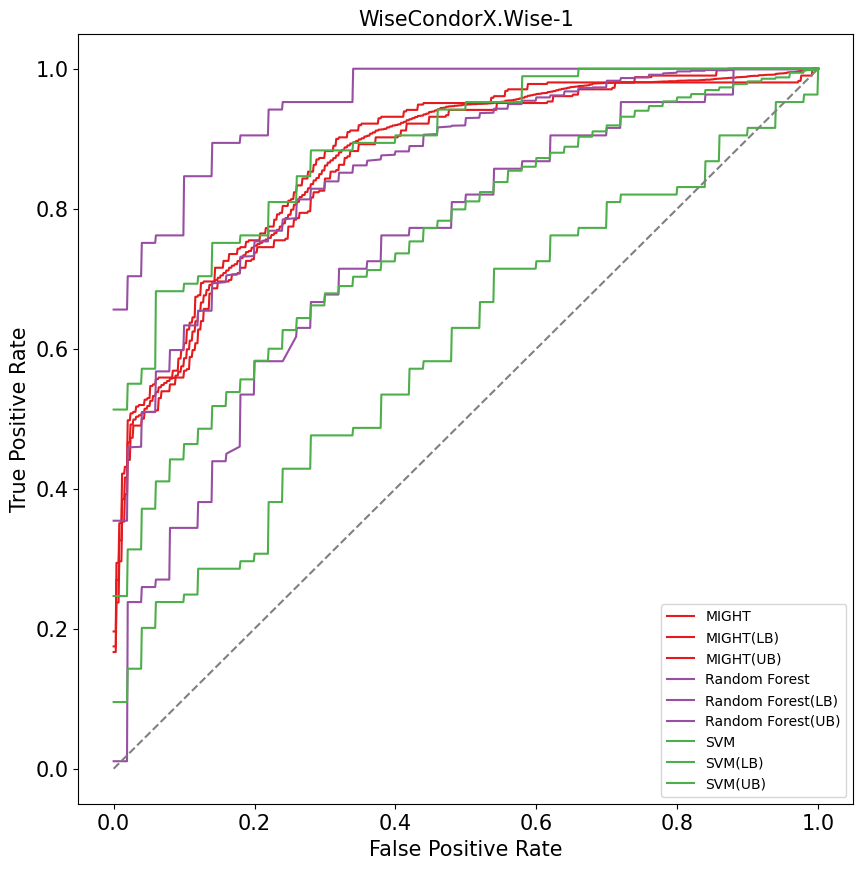

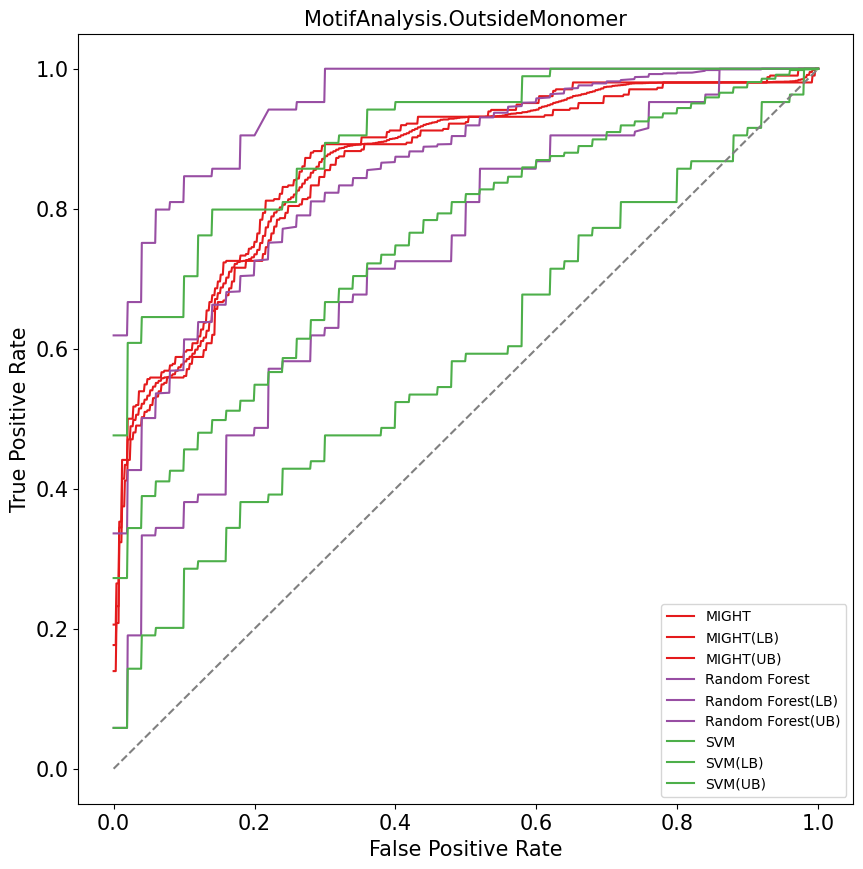

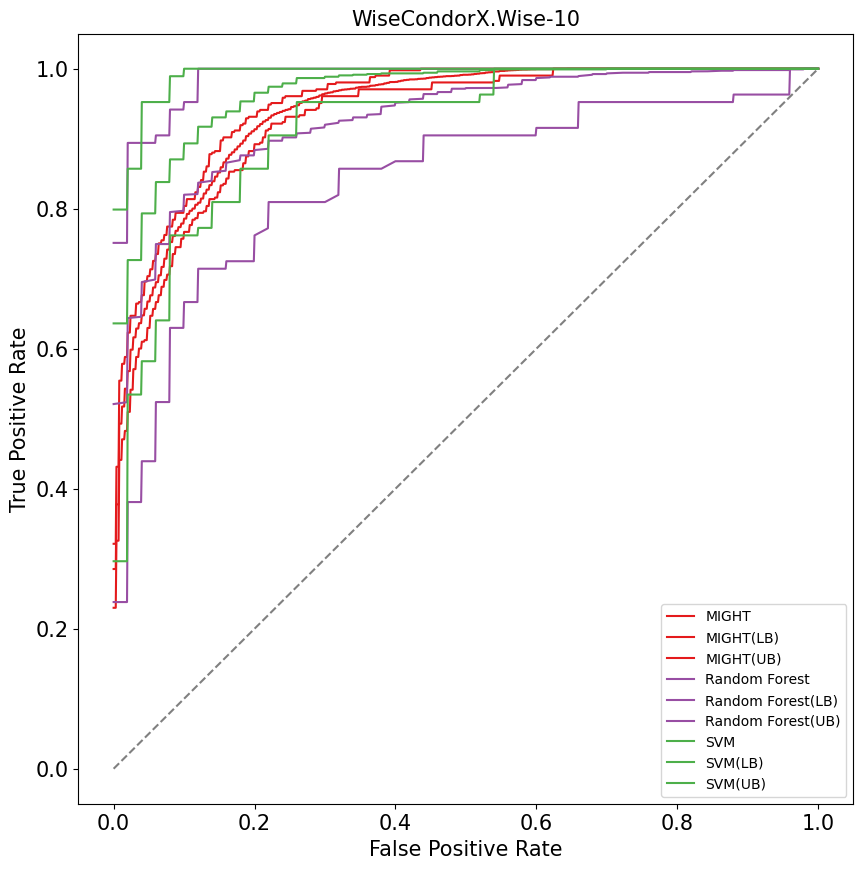

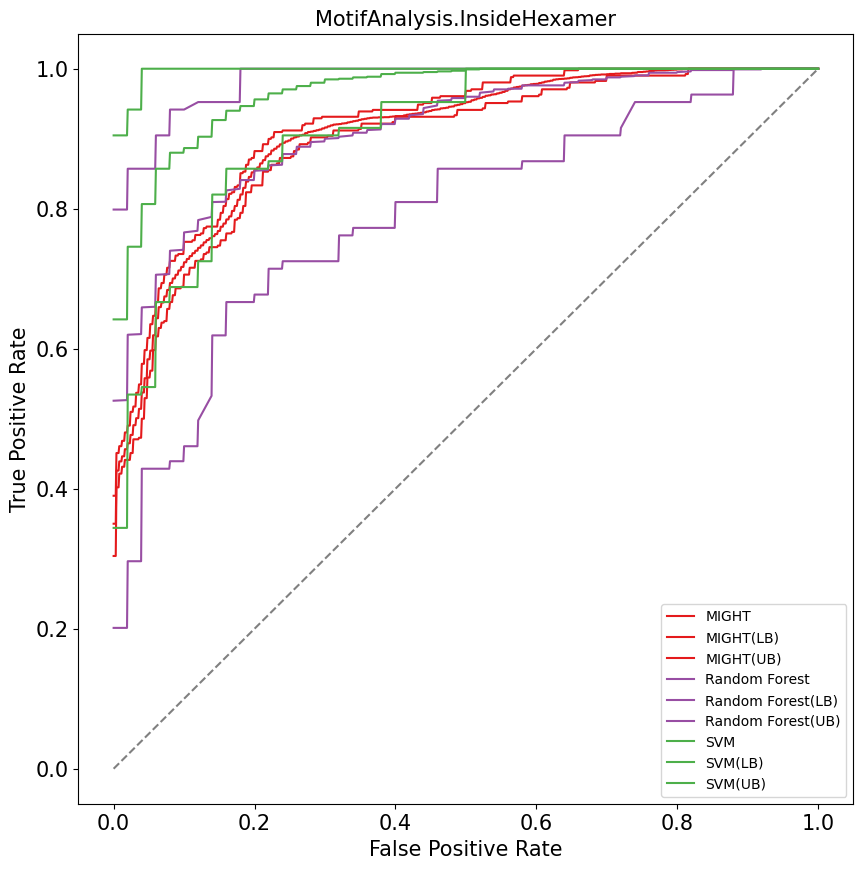

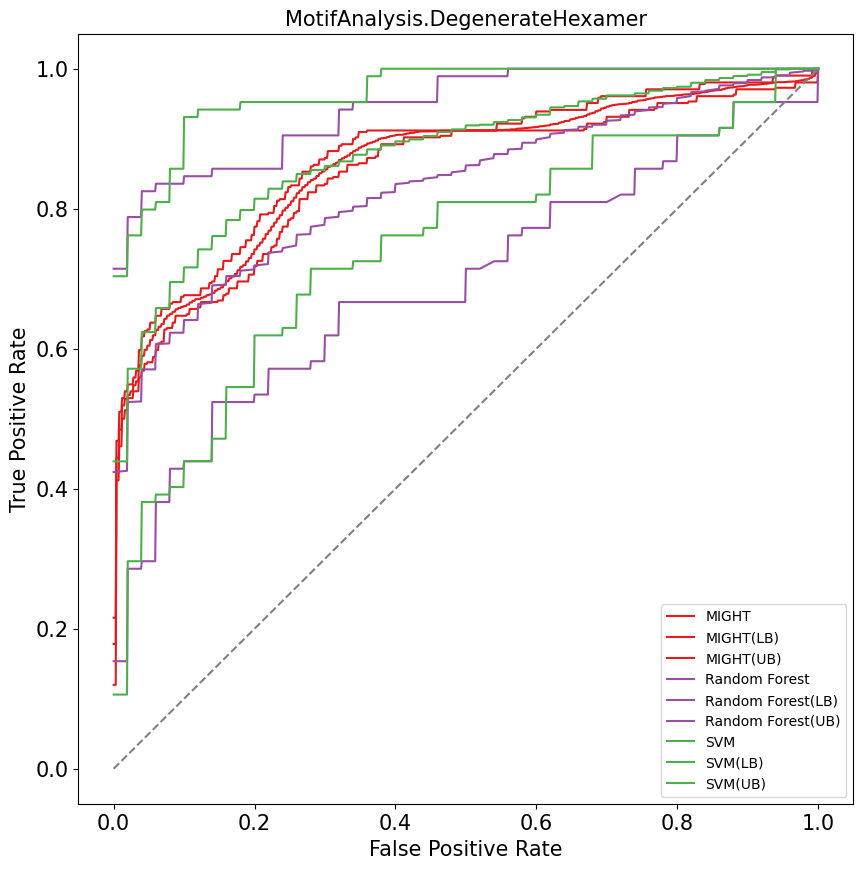

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
# set the style to Set1
sns.set_palette("Set1")
# colors = sns.color_palette("Set1", n_colors=10,as_cmap=False)

FIG_DIR = "./results/figures/"
clf_names = [
    "MIGHT",
    "Random Forest",
    "SVM",
    # "Naive Bayes",
    # "Logistic Regression",
]
n_clf = len(clf_names)
# plot the ROC curve
base_fpr = np.linspace(0, 1, 1001)
N_ITR = int(len(fprs)/len(filelist))
fpr_ls = np.zeros((N_ITR, n_clf, 1001))
tpr_ls = np.zeros((N_ITR, n_clf, 1001))
feature_mean_s = []
n_files = len(filelist)
for i in range(n_files):
    FEATURENAME = filelist[i].split(".csv")[0]
    if FEATURENAME not in list(top5_features):
        continue
    print(FEATURENAME)
    # initialize a figure
    fig, ax = plt.subplots(figsize=(10, 10))
    for j, clf_name_ in enumerate(clf_names):
        tpr_s = []
        for k in range(N_ITR):
            tpr = np.interp(base_fpr, fprs[n_files*k+i][j], tprs[n_files*k+i][j])
            tpr_s.append(tpr)
    # print(tpr.shape)
    # print(np.array(tpr_s).shape)
    # print(np.mean(tpr_s, axis=0).shape)
        # plot the tpr_s with confidence intervals
        ax.plot(base_fpr, np.mean(tpr_s, axis=0), label=clf_names[j], color=colors[j])
        # plot the 95% confidence intervals
        ax.plot(base_fpr, np.percentile(tpr_s, 2.5, axis=0), label=clf_names[j]+"(LB)", color=colors[j])
        ax.plot(base_fpr, np.percentile(tpr_s, 97.5, axis=0), label=clf_names[j]+"(UB)", color=colors[j])
        # ax.plot(base_fpr, np.max(tpr_s, axis=0), label=clf_names[j]+"(max)", color=colors[j])
        # ax.plot(base_fpr, np.min(tpr_s, axis=0), label=clf_names[j]+"(min)", color=colors[j])
        # plot the confidence intervals
        # ax.fill_between(
        #     base_fpr,
        #     np.max(tpr_s, axis=0),
        #     np.min(tpr_s, axis=0),
        #     color=colors[j],
        #     alpha=0.3,
        # )
    plt.legend(fontsize=10)
    ax.plot([0,1], [0,1], "--", color="gray")
    ax.set_xlabel("False Positive Rate", fontsize=15)
    ax.set_ylabel("True Positive Rate", fontsize=15)
    ax.tick_params(axis="both", labelsize=15)
    plt.title(f"{FEATURENAME}", fontsize=15)
    # plt.savefig(FIG_DIR + "roc_" + str(FEATURENAME) + ".png", dpi=120)
    

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# set the style to Set1
sns.set_palette("Set1")
colors = sns.color_palette("Set1", n_colors=10,as_cmap=False)

FIG_DIR = "./results/figures/"
clf_names = [
    "MIGHT",
    "Random Forest",
    "SVM",
    # "Naive Bayes",
    # "Logistic Regression",
]
n_clf = len(clf_names)
# plot the ROC curve
base_fpr = np.linspace(0, 1, 1001)
N_ITR = int(len(fprs)/len(filelist))
fpr_ls = np.zeros((N_ITR, n_clf, 1001))
tpr_ls = np.zeros((N_ITR, n_clf, 1001))
feature_mean_s = []
n_files = len(filelist)
for i, filename in enumerate(filelist[:]):
    FEATURENAME = filename.split(".csv")[0]
    print(FEATURENAME)
    # initialize a figure
    fig, ax = plt.subplots(figsize=(10, 10))
    for j, clf_name_ in enumerate(clf_names):
        tpr_s = []
        for k in range(N_ITR):
            tpr = np.interp(base_fpr, fprs[i+k*n_files][j], tprs[i+k*n_files][j])
            tpr_s.append(tpr)
            ax.plot(base_fpr, tpr, color=colors[j], alpha=0.2)
    # print(tpr.shape)
    # print(np.array(tpr_s).shape)
    # print(np.mean(tpr_s, axis=0).shape)
        # plot the tpr_s with confidence intervals
        # ax.plot(base_fpr, np.mean(tpr_s, axis=0), label=clf_names[j], color=colors[j])
        ax.plot(base_fpr, np.max(tpr_s, axis=0), label=clf_names[j]+"(max)", color=colors[j], alpha=0.5)
        ax.plot(base_fpr, np.min(tpr_s, axis=0), label=clf_names[j]+"(min)", color=colors[j], alpha=0.5)
        # plot the confidence intervals
        # ax.fill_between(
        #     base_fpr,
        #     np.max(tpr_s, axis=0),
        #     np.min(tpr_s, axis=0),
        #     color=colors[j],
        #     alpha=0.3,
        # )
    plt.legend(fontsize=10)
    ax.plot([0,1], [0,1], "--", color="gray")
    ax.set_xlabel("False Positive Rate", fontsize=15)
    ax.set_ylabel("True Positive Rate", fontsize=15)
    ax.tick_params(axis="both", labelsize=15)
    plt.title(f"{FEATURENAME}", fontsize=15)
    # plt.savefig(FIG_DIR + "roc_" + str(FEATURENAME) + ".png", dpi=120)
    

# Plot the TPR and FPR of each models as strip plots

In [12]:
from collections import defaultdict
# N_ITR = 5
FIG_DIR = "./results/figures/"
clf_name = [
    "MIGHT",
    "Random Forest",
    "SVM",
    "Naive Bayes",
    "Logistic Regression",
]
n_clf = len(clf_name)
base_fpr = np.linspace(0, 1, 1001)
max_fpr = 0.02
# create a dataframe to store the results
results_per_feature = pd.DataFrame()
D_sa98 = defaultdict()
n_files = len(filelist)
for i in range(n_files):
    FEATURENAME = filelist[i].split(".csv")[0]
    # print(i, FEATURENAME)
    d_sa98 = defaultdict(list)
    for j, clf in enumerate(clf_name):
        for k in range(N_ITR):
            tpr = np.interp(base_fpr, fprs[i+n_files*k][j], tprs[i+n_files*k][j])
            d_sa98[clf].append(max([tpr for (base_fpr, tpr) in zip(base_fpr, tpr) if base_fpr <= max_fpr]))
    D_sa98[FEATURENAME] = d_sa98

In [13]:
# N_ITR = 5
FIG_DIR = "./results/figures/"
clf_name = [
    "MIGHT",
    "Random Forest",
    "SVM",
    "Naive Bayes",
    "Logistic Regression",
]
n_clf = len(clf_name)
base_fpr = np.linspace(0, 1, 1001)
max_fpr = 0.02
# create a dataframe to store the results
results = pd.DataFrame()
results_per_run = pd.DataFrame()
for i in range(len(filelist)):
    FEATURENAME = filelist[i].split(".csv")[0]
    print(i, FEATURENAME)
    for j in range(n_clf):
        fpr_cv = []
        tpr_ = []
        tpr_cv = []
        sa98_ = []
        for k in range(N_ITR):
            tpr = np.interp(base_fpr, fprs[i+n_files*k][j], tprs[i+n_files*k][j])
            # print(tpr)
            tpr_i = np.mean(tpr, axis=0)
            tpr_.append(tpr_i)
            # tpr_std = np.std(tpr, axis=0)
            sa98_i = max([tpr for (base_fpr, tpr) in zip(base_fpr, tpr) if base_fpr <= max_fpr])
            sa98_.append(sa98_i)
            # add noise
            sa98_i += np.random.normal(0, 0.01, 1)[0]
            row = {
            "Feature": FEATURENAME,
            "Classifier": clf_name[j],
            "sa98": sa98_i,
            "tpr": tpr_i,
            }
            tpr_cv.extend(tpr)
            fpr_cv.extend(base_fpr)
            results_per_run = results_per_run._append(row, ignore_index=True)
        tpr_mean = np.mean(tpr_)
        sa98_cv = max([tpr for (base_fpr, tpr) in zip(fpr_cv, tpr_cv) if base_fpr <= max_fpr])
        sa98 = np.mean(sa98_)
        # print( " "*5, j+1, clf_name[j])
        # print(" "*10, "sa98:", sa98)
        # print(" "*10, "sa98_cv:", sa98_cv)
        # print(" "*10, "tpr:", tpr_mean)
        # add the results to the dataframe
        row = {
            "Feature": FEATURENAME,
            "Classifier": clf_name[j],
            "sa98_mean": sa98,
            "sa98_cv": sa98_cv,
            "tpr": tpr_mean,
        }
        results = results._append(row, ignore_index=True)
        


0 LociFraction.AluFraction
1 LociFraction.cCREFraction
2 LociFraction.LINEsFraction
3 MotifAnalysis.CongruentDimer
4 MotifAnalysis.CongruentHexamer
5 MotifAnalysis.CongruentTetramer
6 MotifAnalysis.DegenerateHexamer
7 MotifAnalysis.DegenerateTetramer
8 MotifAnalysis.InsideDimer
9 MotifAnalysis.InsideHexamer
10 MotifAnalysis.InsideMonomer
11 MotifAnalysis.InsidePentamer
12 MotifAnalysis.InsideTetramer
13 MotifAnalysis.InsideTrimer
14 MotifAnalysis.InsideTrimer0.01
15 MotifAnalysis.InsideTrimer0.05
16 MotifAnalysis.OutsideDimer
17 MotifAnalysis.OutsideHexamer
18 MotifAnalysis.OutsideMonomer
19 MotifAnalysis.OutsidePentamer
20 MotifAnalysis.OutsideTetramer
21 MotifAnalysis.OutsideTrimer
22 WiseCondorX.Wise-1
23 WiseCondorX.Wise-5
24 WiseCondorX.Wise-10
25 Delfi.LengthRatio
26 DyadAccessibility.AluJ
27 DyadAccessibility.AluS
28 DyadAccessibility.AluY
29 DyadAccessibility.BudhrajaRPR
30 DyadAccessibility.cCRE_CTCF
31 DyadAccessibility.cCRE_DistalEnhancers
32 DyadAccessibility.cCRE_DNaseH3K4

In [21]:
# display(results)
# sort the results s.t. the Classifier is in the order of ["MIGHT", "Random Forest", "SVM", "Naive Bayes", "Logistic Regression"]
df = results.set_index("Classifier").loc[["MIGHT", "Random Forest", "SVM", "Naive Bayes", "Logistic Regression"]].sort_values("Feature").reset_index()
display(df)
feature_s98_ranks = df[df["Classifier"] == "MIGHT"].sort_values("sa98_mean", ascending=False)[["Feature", "sa98_mean"]]
top5_features = df[df["Classifier"] == "MIGHT"].sort_values("sa98_mean", ascending=False)[:5]["Feature"]
display(feature_s98_ranks)
# save the results as a csv file
feature_s98_ranks.to_csv("./feature_s98_ranks.csv", index=False)


,Classifier,Feature,sa98_mean,sa98_cv,tpr
0,Random Forest,Delfi.LengthRatio,0.265714,0.428571,0.646363
1,SVM,Delfi.LengthRatio,0.290476,0.619048,0.719100
2,MIGHT,Delfi.LengthRatio,0.254706,0.254902,0.644859
3,Logistic Regression,Delfi.LengthRatio,0.315238,0.619048,0.717330
4,Naive Bayes,Delfi.LengthRatio,0.138125,0.476190,0.618697
...,...,...,...,...,...
215,MIGHT,ichorCNA.ichorCNA,0.533922,0.549020,0.861095
216,Naive Bayes,ichorCNA.ichorCNA,0.368667,0.533333,0.679592
217,Logistic Regression,ichorCNA.ichorCNA,0.555238,0.809524,0.843813
218,Random Forest,ichorCNA.ichorCNA,0.523810,0.809524,0.832205


,Feature,sa98_mean
200,WiseCondorX.Wise-1,0.568039
215,ichorCNA.ichorCNA,0.533922
193,MotifAnalysis.OutsideTetramer,0.470392
186,MotifAnalysis.OutsidePentamer,0.466078
211,WiseCondorX.Wise-5,0.464902
208,WiseCondorX.Wise-10,0.453137
15,DyadAccessibility.AluY,0.447255
60,LengthAnalysis.Length1,0.446471
7,DyadAccessibility.AluJ,0.438431
24,DyadAccessibility.BudhrajaRPR,0.431176


In [20]:
# display(results)
# sort the results s.t. the Classifier is in the order of ["MIGHT", "Random Forest", "SVM", "Naive Bayes", "Logistic Regression"]
df_per_run = results_per_run.set_index("Classifier").loc[["MIGHT", "Random Forest", "SVM", "Naive Bayes", "Logistic Regression"]].sort_values("Feature").reset_index()
display(df_per_run)

,Classifier,Feature,sa98,tpr
0,MIGHT,Delfi.LengthRatio,0.382353,0.739711
1,Naive Bayes,Delfi.LengthRatio,0.285714,0.653680
2,Naive Bayes,Delfi.LengthRatio,0.285714,0.662243
3,Naive Bayes,Delfi.LengthRatio,0.380952,0.642262
4,Naive Bayes,Delfi.LengthRatio,0.333333,0.744065
...,...,...,...,...
10995,Naive Bayes,ichorCNA.ichorCNA,0.037037,0.586152
10996,Naive Bayes,ichorCNA.ichorCNA,0.174603,0.712644
10997,Naive Bayes,ichorCNA.ichorCNA,0.095238,0.679844
10998,Naive Bayes,ichorCNA.ichorCNA,0.261905,0.742163


<Figure size 1500x1000 with 0 Axes>

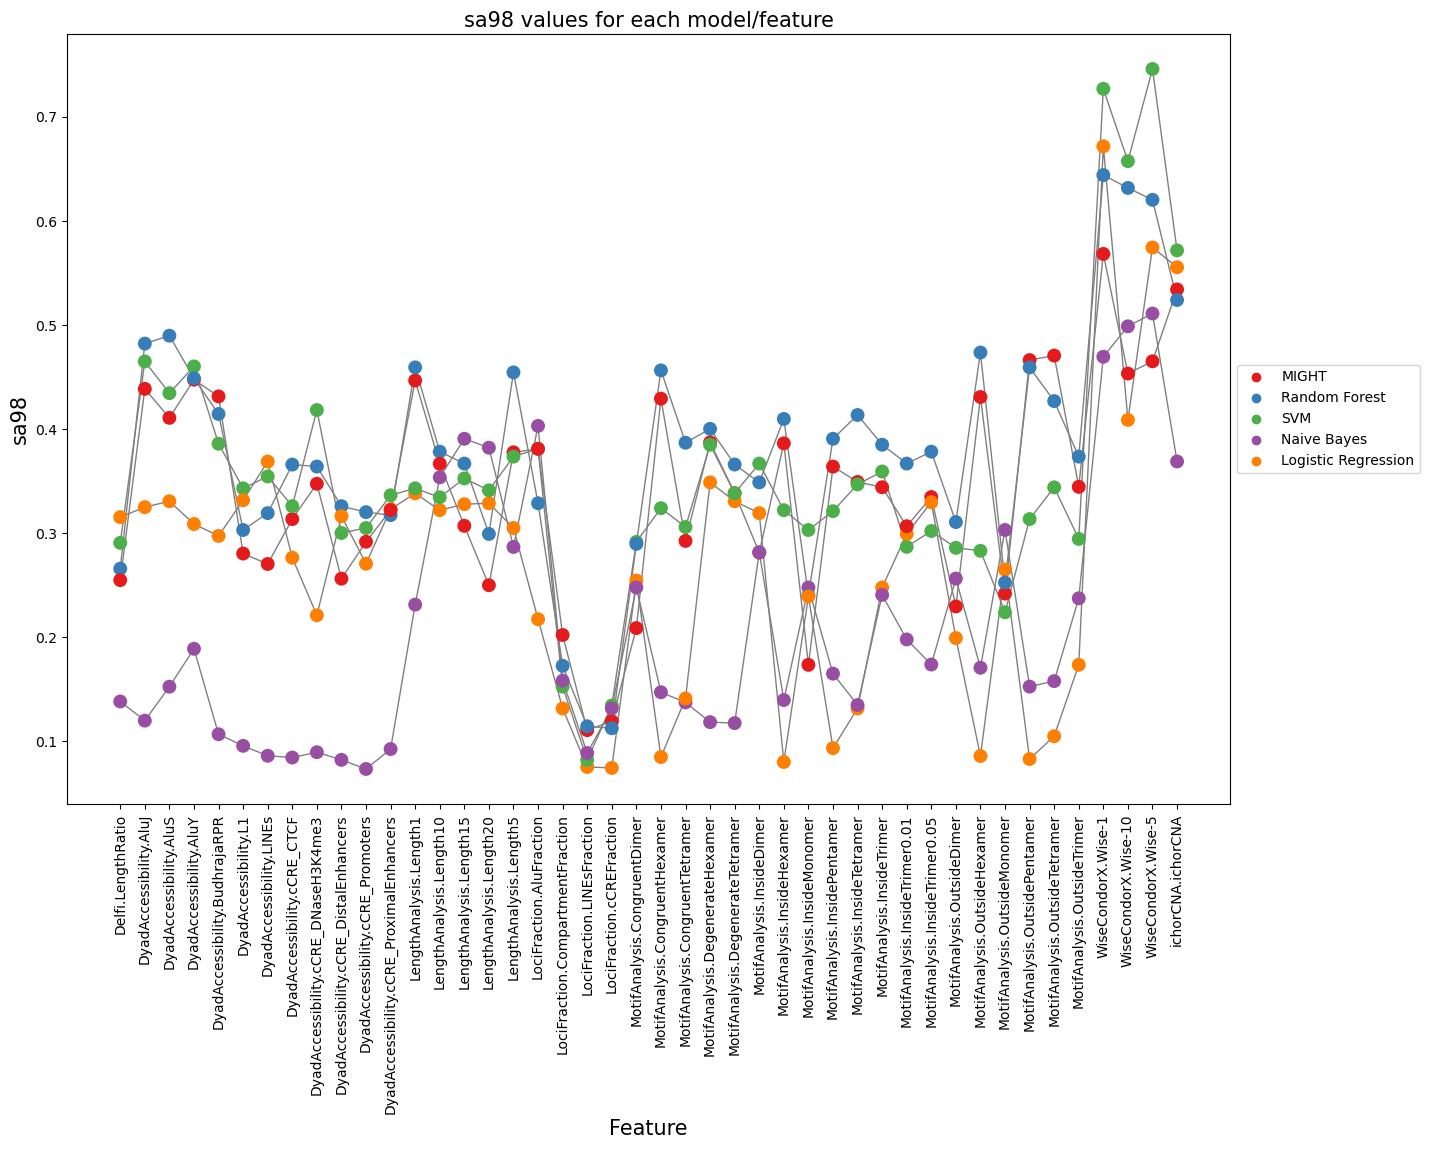

In [17]:
# plot as a stripplot with the sa98 values for each feature
plt.figure(figsize=(15, 10))
# Define a custom color mapping for classifiers
color_mapping = {
    "MIGHT": "red",
    "Random Forest": "blue",
    "SVM": "green",
    "Naive Bayes": "purple",
    "Logistic Regression": "orange"
}

# Create a list of colors in the order of the classifiers appearing in the data
# This ensures that each classifier is colored according to the custom mapping
classifier_colors = [color_mapping[classifier] for classifier in results["Classifier"].unique()]
# sns.set_palette(classifier_colors)
plt.figure(figsize=(15, 10))
# Apply the custom color palette
# sns.set_palette(classifier_colors)
# sort the results by the feature name
features = df["Feature"].unique()
classifiers = [ "MIGHT", "Random Forest", "SVM","Naive Bayes", "Logistic Regression"]#df["Classifier"].unique()
# change the hues so the "MIGHT" is red, "Random Forest" is blue, "SVM" is green, "Naive Bayes" is orange, and "Logistic Regression" is purple
sns.set_palette(sns.color_palette("Set1", 5))
sns.stripplot(x="Feature", y="sa98_mean", hue="Classifier", data=df, jitter=False, dodge=False, size=10, order=features, hue_order=classifiers)
# Manually specify the order and labels for the legend
# legend_order = ["MIGHT", "Random Forest", "SVM", "Naive Bayes", "Logistic Regression"]
# legend_colors = [color_mapping[classifier] for classifier in legend_order]

# Create custom legend
# custom_legend = [plt.Line2D([0], [0], color=color, marker='o', linestyle='', markersize=10) for color in legend_colors]
plt.legend()
# plot the sa98 values for each classifier
for classifier in classifiers:
    classifier_data = df[df["Classifier"] == classifier]
    y_values = classifier_data["sa98_mean"].values
    # Get the x-values (positions) for the current feature across classifiers
    # This assumes the classifiers are evenly spaced and ordered
    x_values = np.arange(len(features))
    # Draw lines between the points for the current feature
    plt.plot(x_values, y_values, color="gray", linestyle='-', linewidth=1)

# for i, classifier in enumerate(classifiers):
#     classifier_data_per_run = df_per_run[df_per_run["Classifier"] == classifier]
#     sns.stripplot(x="Feature", y="sa98", hue="Classifier", data=classifier_data_per_run, jitter=False, dodge=False, size=5, order=features, hue_order=classifiers)
   
plt.xticks(rotation=90)
plt.xlabel("Feature", fontsize=15)
plt.ylabel("sa98", fontsize=15)
# move the legend to the right
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("sa98 values for each model/feature", fontsize=15)
# save the plot
plt.savefig(FIG_DIR + "cancer44_sa98_stripplot.png", dpi=120)



<Figure size 1500x1000 with 0 Axes>

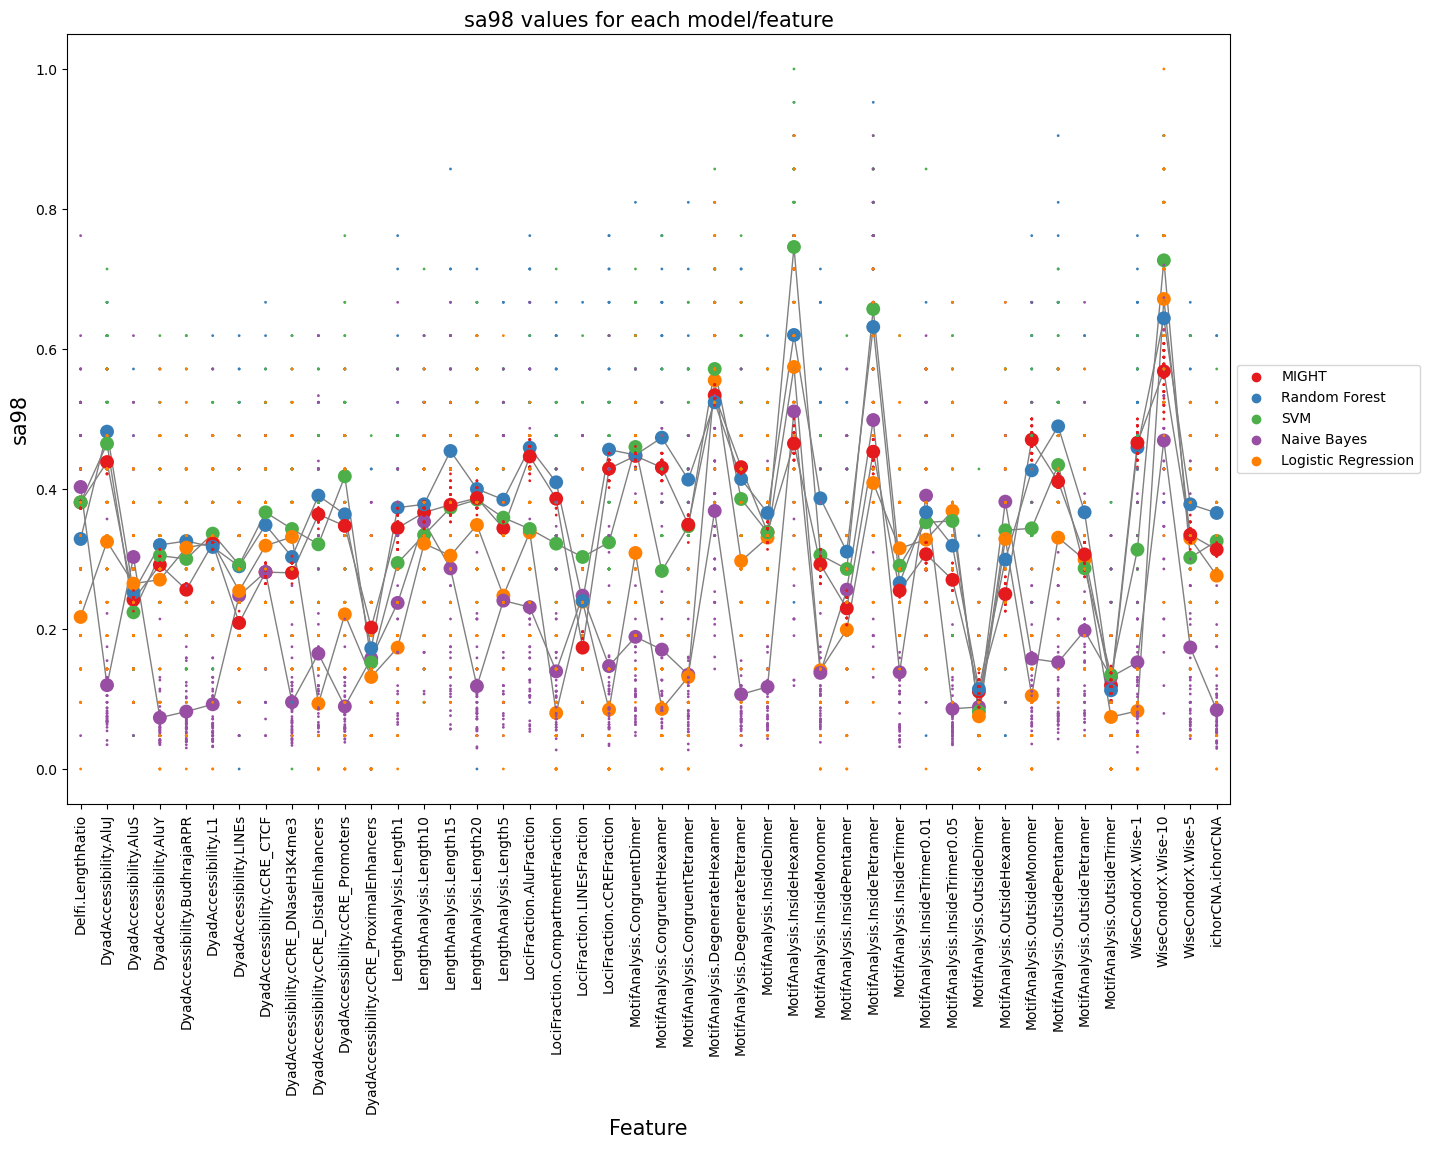

In [22]:
# plot as a stripplot with the sa98 values for each feature
plt.figure(figsize=(15, 10))
# Define a custom color mapping for classifiers
color_mapping = {
    "MIGHT": "red",
    "Random Forest": "blue",
    "SVM": "green",
    "Naive Bayes": "purple",
    "Logistic Regression": "orange"
}

# Create a list of colors in the order of the classifiers appearing in the data
# This ensures that each classifier is colored according to the custom mapping
classifier_colors = [color_mapping[classifier] for classifier in results["Classifier"].unique()]
# sns.set_palette(classifier_colors)
plt.figure(figsize=(15, 10))
# Apply the custom color palette
# sns.set_palette(classifier_colors)
# sort the results by the feature name
features = df["Feature"].unique()
classifiers = [ "MIGHT", "Random Forest", "SVM","Naive Bayes", "Logistic Regression"]#df["Classifier"].unique()
# change the hues so the "MIGHT" is red, "Random Forest" is blue, "SVM" is green, "Naive Bayes" is orange, and "Logistic Regression" is purple
sns.set_palette(sns.color_palette("Set1", 5))
sns.stripplot(x="Feature", y="sa98", hue="Classifier", data=df, jitter=False, dodge=False, size=10, order=features, hue_order=classifiers)
# Manually specify the order and labels for the legend
# legend_order = ["MIGHT", "Random Forest", "SVM", "Naive Bayes", "Logistic Regression"]
# legend_colors = [color_mapping[classifier] for classifier in legend_order]

# Create custom legend
# custom_legend = [plt.Line2D([0], [0], color=color, marker='o', linestyle='', markersize=10) for color in legend_colors]
plt.legend()
# plot the sa98 values for each classifier
for classifier in classifiers:
    classifier_data = df[df["Classifier"] == classifier]
    y_values = classifier_data["sa98"].values
    # Get the x-values (positions) for the current feature across classifiers
    # This assumes the classifiers are evenly spaced and ordered
    x_values = np.arange(len(features))
    # Draw lines between the points for the current feature
    plt.plot(x_values, y_values, color="gray", linestyle='-', linewidth=1)

for i, classifier in enumerate(classifiers):
    classifier_data_per_run = df_per_run[df_per_run["Classifier"] == classifier]
    sns.stripplot(x="Feature", y="sa98", hue="Classifier", data=classifier_data_per_run, jitter=False, dodge=False, size=2, order=features, hue_order=classifiers,legend=False)
   
plt.xticks(rotation=90)
plt.xlabel("Feature", fontsize=15)
plt.ylabel("sa98", fontsize=15)
# move the legend to the right
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("sa98 values for each model/feature", fontsize=15)
# save the plot
plt.savefig(FIG_DIR + "cancer44_sa98_stripplot.png", dpi=120)



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 1.0, 'sa98 values for each model/feature')

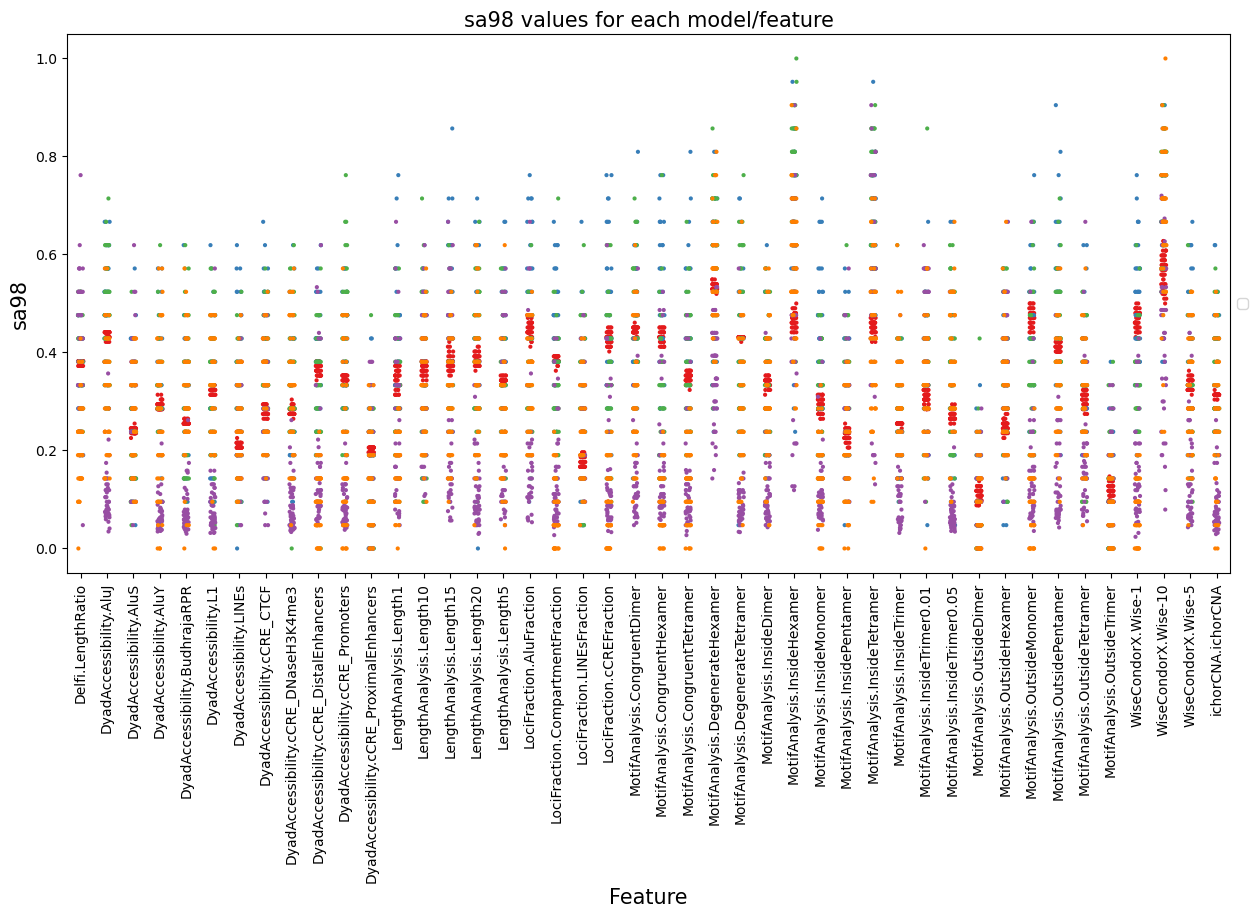

In [23]:
# plot as a stripplot with the sa98 values for each feature
plt.figure(figsize=(15, 7))
# Define a custom color mapping for classifiers
color_mapping = {
    "MIGHT": "red",
    "Random Forest": "blue",
    "SVM": "green",
    "Naive Bayes": "purple",
    "Logistic Regression": "orange"
}

# Create a list of colors in the order of the classifiers appearing in the data
# This ensures that each classifier is colored according to the custom mapping
classifier_colors = [color_mapping[classifier] for classifier in results["Classifier"].unique()]
# sns.set_palette(classifier_colors)
# Apply the custom color palette
# sns.set_palette(classifier_colors)
# sort the results by the feature name
features = df["Feature"].unique()
classifiers = [ "MIGHT", "Random Forest", "SVM","Naive Bayes", "Logistic Regression"]#df["Classifier"].unique()
# change the hues so the "MIGHT" is red, "Random Forest" is blue, "SVM" is green, "Naive Bayes" is orange, and "Logistic Regression" is purple
sns.set_palette(sns.color_palette("Set1", 5))
# sns.stripplot(x="Feature", y="sa98", hue="Classifier", data=df, jitter=False, dodge=False, size=10, order=features, hue_order=classifiers)
# # Manually specify the order and labels for the legend
# # legend_order = ["MIGHT", "Random Forest", "SVM", "Naive Bayes", "Logistic Regression"]
# # legend_colors = [color_mapping[classifier] for classifier in legend_order]

# # Create custom legend
# # custom_legend = [plt.Line2D([0], [0], color=color, marker='o', linestyle='', markersize=10) for color in legend_colors]
# plt.legend()
# # plot the sa98 values for each classifier
# for classifier in classifiers:
#     classifier_data = df[df["Classifier"] == classifier]
#     y_values = classifier_data["sa98"].values
#     # Get the x-values (positions) for the current feature across classifiers
#     # This assumes the classifiers are evenly spaced and ordered
#     x_values = np.arange(len(features))
#     # Draw lines between the points for the current feature
#     plt.plot(x_values, y_values, color="gray", linestyle='-', linewidth=1)

for i, classifier in enumerate(classifiers):
    classifier_data_per_run = df_per_run[df_per_run["Classifier"] == classifier]
    sns.stripplot(x="Feature", y="sa98", hue="Classifier", data=classifier_data_per_run, jitter=True, dodge=False, size=3, order=features, hue_order=classifiers,legend=False)
   
plt.xticks(rotation=90)
plt.xlabel("Feature", fontsize=15)
plt.ylabel("sa98", fontsize=15)
# move the legend to the right
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("sa98 values for each model/feature", fontsize=15)
# save the plot
# plt.savefig(FIG_DIR + "cancer44_sa98_stripplot.png", dpi=120)



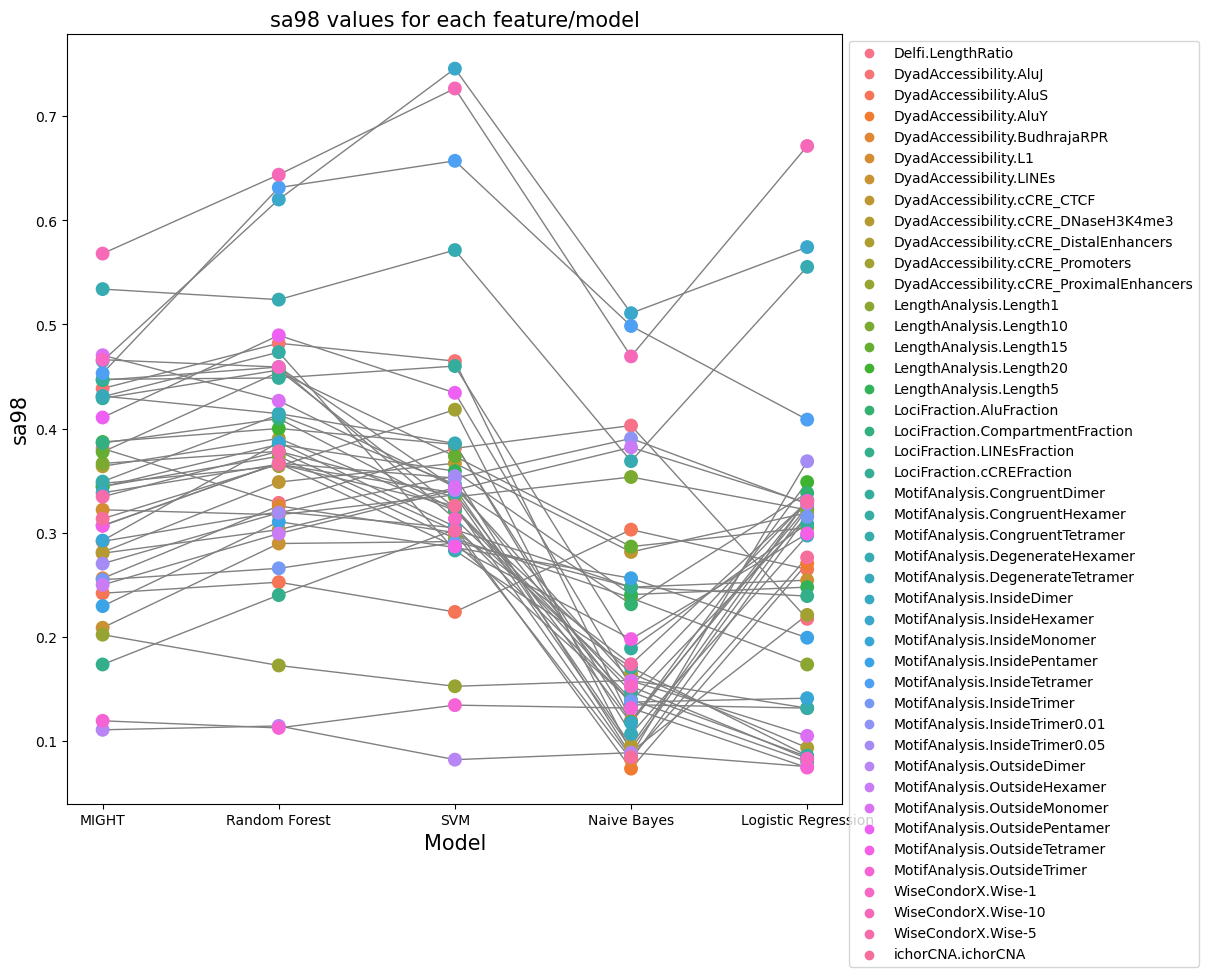

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming 'results' is your DataFrame and it's already sorted by "Feature"
# Example DataFrame creation for demonstration (replace this with your actual DataFrame)
# results = pd.DataFrame({
#     "Classifier": np.repeat(["A", "B", "C"], 5),
#     "sa98": np.random.rand(15),
#     "Feature": np.tile(["F1", "F2", "F3", "F4", "F5"], 3)
# })
# Get the unique classifiers and features for iteration
classifiers = results["Classifier"].unique()
features = results["Feature"].unique()

plt.figure(figsize=(10, 10))
sns.set_palette(sns.color_palette("Set1", 5))
sns.stripplot(x="Classifier", y="sa98", hue="Feature", data=results.sort_values("Feature"), jitter=False, dodge=False, size=10, linewidth=0, order=classifiers)

# Iterate through each feature to draw lines
for feature in features:
    # Filter the DataFrame for the current feature
    feature_data = results[results["Feature"] == feature]
    # Get the y-values (sa98 values) for the current feature
    y_values = feature_data["sa98"].values
    # Get the x-values (positions) for the current feature across classifiers
    # This assumes the classifiers are evenly spaced and ordered
    x_values = np.arange(len(classifiers))
    # Draw lines between the points for the current feature
    plt.plot(x_values, y_values, color="gray", linestyle='-', linewidth=1)

plt.xlabel("Model", fontsize=15)
plt.ylabel("sa98", fontsize=15)
plt.title("sa98 values for each feature/model", fontsize=15)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.savefig(FIG_DIR + "cancer44_sa98_stripplot_per_model_with_lines.png", dpi=120)

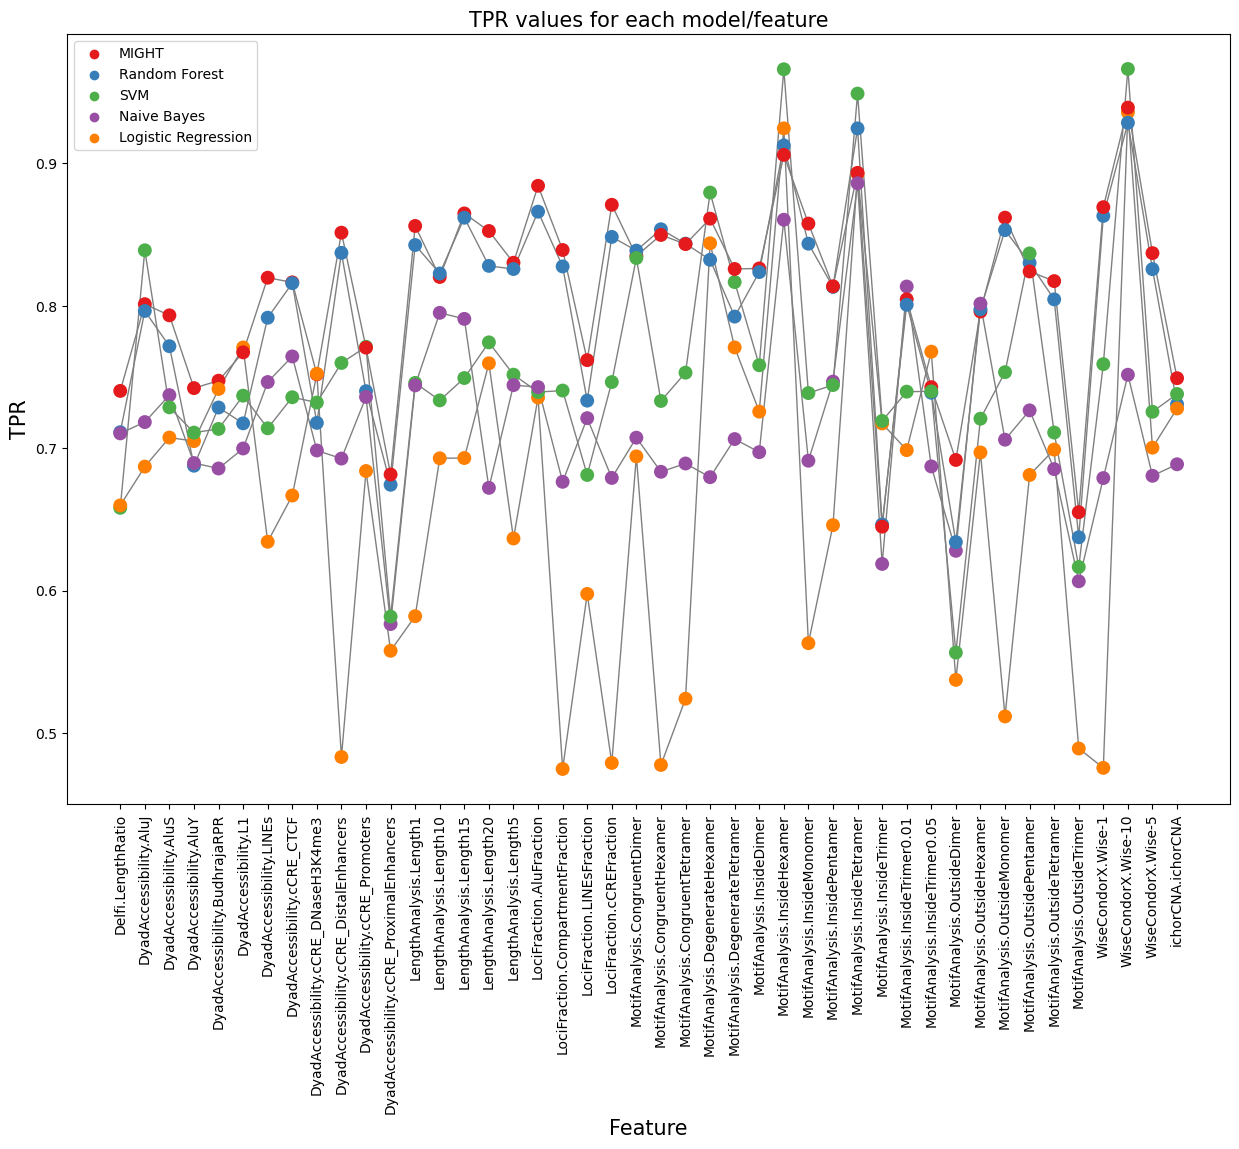

In [25]:
# plot as a stripplot with the sa98 values for each feature
plt.figure(figsize=(15, 10))
# change the hues so the "MIGHT" is red, "Random Forest" is blue, "SVM" is green, "Naive Bayes" is orange, and "Logistic Regression" is purple
sns.set_palette(sns.color_palette("Set1", 5))
sns.stripplot(x="Feature", y="tpr", hue="Classifier", data=df, jitter=False, dodge=False, size=10, hue_order=classifiers)
classifiers = [ "MIGHT", "Random Forest", "SVM","Naive Bayes", "Logistic Regression"]
plt.legend()
# plot the sa98 values for each classifier
for classifier in classifiers:
    classifier_data = df.sort_values("Feature")[df["Classifier"] == classifier]
    y_values = classifier_data["tpr"].values
    # Get the x-values (positions) for the current feature across classifiers
    # This assumes the classifiers are evenly spaced and ordered
    x_values = np.arange(len(features))
    # Draw lines between the points for the current feature
    plt.plot(x_values, y_values, color="gray", linestyle='-', linewidth=1)

plt.xticks(rotation=90)
plt.xlabel("Feature", fontsize=15)
plt.ylabel("TPR", fontsize=15)
plt.title("TPR values for each model/feature", fontsize=15)
# save the plot
plt.savefig(FIG_DIR + "cancer44_tpr_stripplot.png", dpi=120)

Text(0.5, 1.0, 'tpr values for each model/feature')

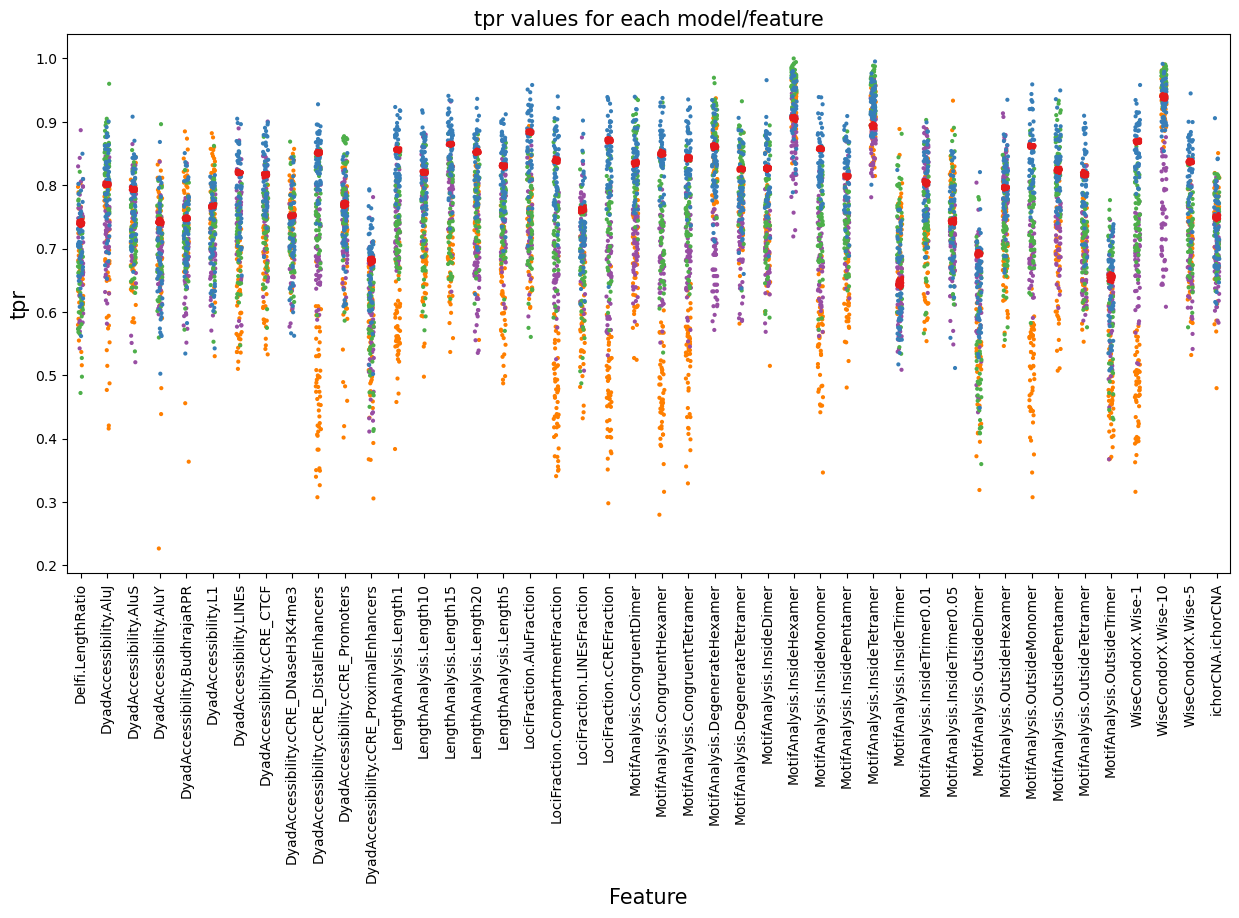

In [30]:
# plot as a stripplot with the sa98 values for each feature
plt.figure(figsize=(15, 7))
# Define a custom color mapping for classifiers
color_mapping = {
    "MIGHT": "red",
    "Random Forest": "blue",
    "SVM": "green",
    "Naive Bayes": "purple",
    "Logistic Regression": "orange"
}

# Create a list of colors in the order of the classifiers appearing in the data
# This ensures that each classifier is colored according to the custom mapping
classifier_colors = [color_mapping[classifier] for classifier in results["Classifier"].unique()]
# sns.set_palette(classifier_colors)
# Apply the custom color palette
# sns.set_palette(classifier_colors)
# sort the results by the feature name
features = df["Feature"].unique()
classifiers = [ "MIGHT", "Random Forest", "SVM","Naive Bayes", "Logistic Regression"]#df["Classifier"].unique()
# change the hues so the "MIGHT" is red, "Random Forest" is blue, "SVM" is green, "Naive Bayes" is orange, and "Logistic Regression" is purple
sns.set_palette(sns.color_palette("Set1", 5))
# sns.stripplot(x="Feature", y="sa98", hue="Classifier", data=df, jitter=False, dodge=False, size=10, order=features, hue_order=classifiers)
# # Manually specify the order and labels for the legend
# # legend_order = ["MIGHT", "Random Forest", "SVM", "Naive Bayes", "Logistic Regression"]
# # legend_colors = [color_mapping[classifier] for classifier in legend_order]

# # Create custom legend
# # custom_legend = [plt.Line2D([0], [0], color=color, marker='o', linestyle='', markersize=10) for color in legend_colors]
# plt.legend()
# # plot the sa98 values for each classifier
# for classifier in classifiers:
#     classifier_data = df[df["Classifier"] == classifier]
#     y_values = classifier_data["sa98"].values
#     # Get the x-values (positions) for the current feature across classifiers
#     # This assumes the classifiers are evenly spaced and ordered
#     x_values = np.arange(len(features))
#     # Draw lines between the points for the current feature
#     plt.plot(x_values, y_values, color="gray", linestyle='-', linewidth=1)

for i, classifier in enumerate(classifiers[::-1]):
    classifier_data_per_run = df_per_run[df_per_run["Classifier"] == classifier]
    sns.stripplot(x="Feature", y="tpr", hue="Classifier", data=classifier_data_per_run, jitter=True, dodge=False, size=3, order=features, hue_order=classifiers,legend=False)

plt.xticks(rotation=90)
plt.xlabel("Feature", fontsize=15)
plt.ylabel("tpr", fontsize=15)
# move the legend to the right
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("tpr values for each model/feature", fontsize=15)
# save the plot
# plt.savefig(FIG_DIR + "cancer44_sa98_stripplot.png", dpi=120)

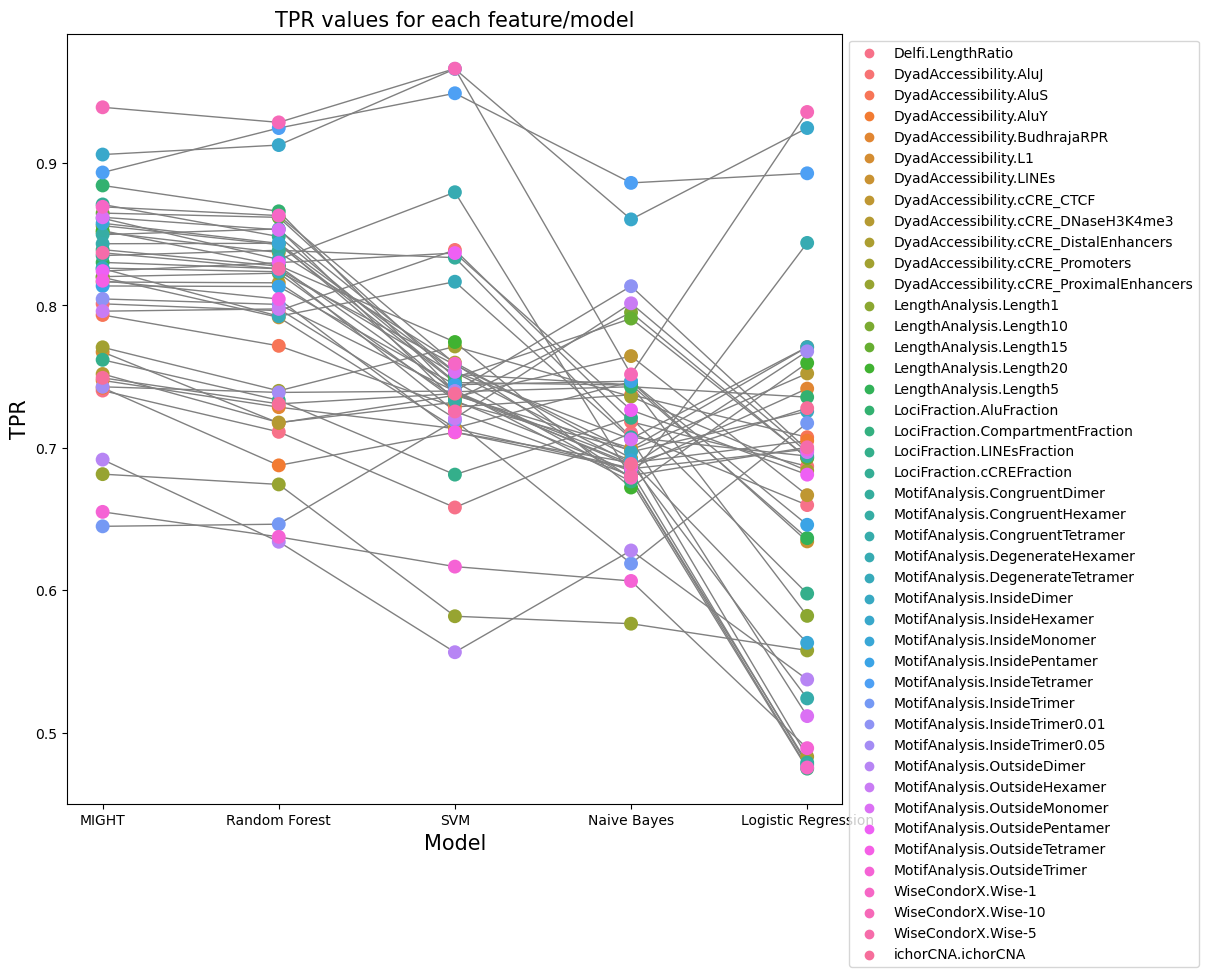

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming 'results' is your DataFrame and it's already sorted by "Feature"
# Example DataFrame creation for demonstration (replace this with your actual DataFrame)
# results = pd.DataFrame({
#     "Classifier": np.repeat(["A", "B", "C"], 5),
#     "sa98": np.random.rand(15),
#     "Feature": np.tile(["F1", "F2", "F3", "F4", "F5"], 3)
# })
# Get the unique classifiers and features for iteration
classifiers = results["Classifier"].unique()
features = results["Feature"].unique()

plt.figure(figsize=(10, 10))
sns.set_palette(sns.color_palette("Set1", 5))
sns.stripplot(x="Classifier", y="tpr", hue="Feature", data=results.sort_values("Feature"), jitter=False, dodge=False, size=10, linewidth=0, order=classifiers)

# Iterate through each feature to draw lines
for feature in features:
    # Filter the DataFrame for the current feature
    feature_data = results[results["Feature"] == feature]
    # Get the y-values (sa98 values) for the current feature
    y_values = feature_data["tpr"].values
    # Get the x-values (positions) for the current feature across classifiers
    # This assumes the classifiers are evenly spaced and ordered
    x_values = np.arange(len(classifiers))
    # Draw lines between the points for the current feature
    plt.plot(x_values, y_values, color="gray", linestyle='-', linewidth=1)

plt.xlabel("Model", fontsize=15)
plt.ylabel("TPR", fontsize=15)
plt.title("TPR values for each feature/model", fontsize=15)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.savefig(FIG_DIR + "cancer44_TPR_stripplot_per_model_with_lines.png", dpi=120)